<a href="https://colab.research.google.com/github/syedahijabzahra/DevelopersHub-AI-ML-Internship/blob/main/Phase_2/Auto_Tagging_Support_Tickets/auto_tagging_support_tickets.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

config.json:   0%|          | 0.00/1.15k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

=== Auto Tagging Results ===

Ticket 1: My internet connection keeps dropping every few minutes, very frustrating.
Top 3 Tags:
  - Technical Issue: 0.954
  - Performance Issue: 0.946
  - Delivery Issue: 0.672

Ticket 2: I was charged twice for my subscription this month, please refund the extra amount.
Top 3 Tags:
  - Subscription Management: 0.946
  - Billing Issue: 0.874
  - Delivery Issue: 0.654

Ticket 3: The mobile app crashes every time I try to upload a photo.
Top 3 Tags:
  - Technical Issue: 0.965
  - Performance Issue: 0.964
  - Delivery Issue: 0.454

Ticket 4: I forgot my password and the reset link is not working.
Top 3 Tags:
  - Technical Issue: 0.919
  - Performance Issue: 0.621
  - Subscription Management: 0.528

Ticket 5: The product I received is damaged and doesn't match the description.
Top 3 Tags:
  - Technical Issue: 0.704
  - Delivery Issue: 0.694
  - Product Quality: 0.576

Ticket 6: Can you explain how to upgrade my current plan to the premium tier?
Top 3 Tags:
 

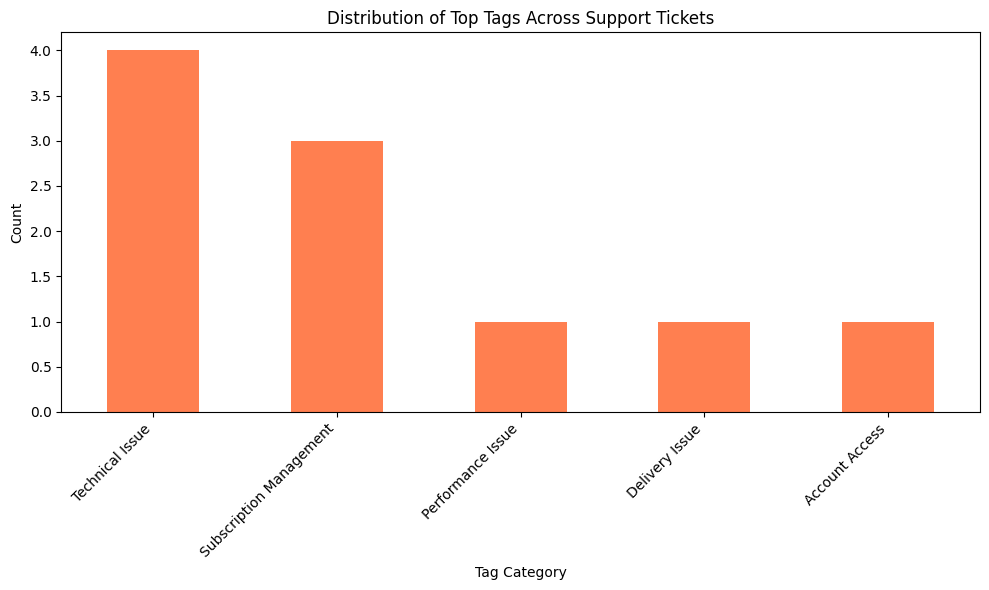

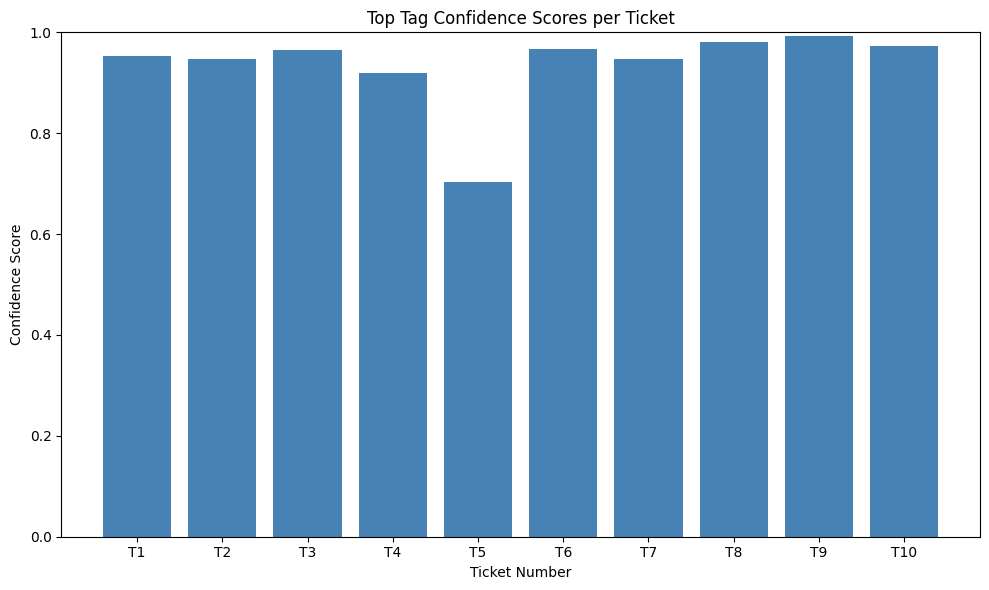


✅ Zero-shot classification complete!
Average confidence score: 0.934


In [1]:
# Auto Tagging Support Tickets Using LLM
# Zero-shot and Few-shot Classification with Transformers

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import pipeline
import warnings
warnings.filterwarnings('ignore')

# Sample support ticket dataset (free-text tickets)
tickets = [
    "My internet connection keeps dropping every few minutes, very frustrating.",
    "I was charged twice for my subscription this month, please refund the extra amount.",
    "The mobile app crashes every time I try to upload a photo.",
    "I forgot my password and the reset link is not working.",
    "The product I received is damaged and doesn't match the description.",
    "Can you explain how to upgrade my current plan to the premium tier?",
    "Your website is extremely slow and pages take forever to load.",
    "I want to cancel my subscription and get a refund for this month.",
    "The delivery is delayed by more than a week with no updates.",
    "I'm getting an error message when trying to log into my account."
]

# Candidate tags (categories)
candidate_tags = [
    "Billing Issue",
    "Technical Issue",
    "Account Access",
    "Product Quality",
    "Subscription Management",
    "Performance Issue",
    "Delivery Issue",
    "General Inquiry"
]

# Load zero-shot classification pipeline
classifier = pipeline("zero-shot-classification", model="facebook/bart-large-mnli")

# Function to get top 3 tags per ticket
def get_top_tags(ticket, candidate_labels, top_n=3):
    result = classifier(ticket, candidate_labels, multi_label=True)
    sorted_results = sorted(zip(result['labels'], result['scores']), key=lambda x: x[1], reverse=True)
    return sorted_results[:top_n]

# Process all tickets
results_data = []
print("=== Auto Tagging Results ===\n")
for i, ticket in enumerate(tickets):
    top_tags = get_top_tags(ticket, candidate_tags)
    print(f"Ticket {i+1}: {ticket}")
    print("Top 3 Tags:")
    for tag, score in top_tags:
        print(f"  - {tag}: {score:.3f}")
    print()

    results_data.append({
        'Ticket': ticket[:50] + "...",
        'Top Tag': top_tags[0][0],
        'Top Score': top_tags[0][1],
        'Tag 2': top_tags[1][0],
        'Tag 3': top_tags[2][0]
    })

# Create results dataframe
results_df = pd.DataFrame(results_data)
print("\n=== Summary Table ===")
print(results_df.to_string(index=False))

# Visualize tag distribution
plt.figure(figsize=(10,6))
results_df['Top Tag'].value_counts().plot(kind='bar', color='coral')
plt.title('Distribution of Top Tags Across Support Tickets')
plt.xlabel('Tag Category')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Confidence score distribution
plt.figure(figsize=(10,6))
plt.bar(range(len(results_df)), results_df['Top Score'], color='steelblue')
plt.title('Top Tag Confidence Scores per Ticket')
plt.xlabel('Ticket Number')
plt.ylabel('Confidence Score')
plt.xticks(range(len(results_df)), [f"T{i+1}" for i in range(len(results_df))])
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

print("\n✅ Zero-shot classification complete!")
print(f"Average confidence score: {results_df['Top Score'].mean():.3f}")